# 自动微分
:label:`sec_autograd`

正如 :numref:`sec_calculus`中所说，求导是几乎所有深度学习优化算法的关键步骤。
虽然求导的计算很简单，只需要一些基本的微积分。
但对于复杂的模型，手工进行更新是一件很痛苦的事情（而且经常容易出错）。

深度学习框架通过自动计算导数，即*自动微分*（automatic differentiation）来加快求导。
实际中，根据设计好的模型，系统会构建一个*计算图*（computational graph），
来跟踪计算是哪些数据通过哪些操作组合起来产生输出。
自动微分使系统能够随后反向传播梯度。
这里，*反向传播*（backpropagate）意味着跟踪整个计算图，填充关于每个参数的偏导数。

## 一个简单的例子

作为一个演示例子，(**假设我们想对函数$y=2\mathbf{x}^{\top}\mathbf{x}$关于列向量$\mathbf{x}$求导**)。
首先，我们创建变量`x`并为其分配一个初始值。


In [1]:
import torch
import pandas as pd

x = torch.arange(4.0)
x

tensor([0., 1., 2., 3.])

[**在我们计算$y$关于$\mathbf{x}$的梯度之前，需要一个地方来存储梯度。**]
重要的是，我们不会在每次对一个参数求导时都分配新的内存。
因为我们经常会成千上万次地更新相同的参数，每次都分配新的内存可能很快就会将内存耗尽。
注意，一个标量函数关于向量$\mathbf{x}$的梯度是向量，并且与$\mathbf{x}$具有相同的形状。


In [2]:
x.requires_grad_(True)  # 等价于x=torch.arange(4.0,requires_grad=True)
x.grad  # 默认值是None

现在计算*y*

In [3]:
y = 2 * torch.dot(x,x)
y

tensor(28., grad_fn=<MulBackward0>)

`x`是一个长度为4的向量，计算`x`和`x`的点积，得到了我们赋值给`y`的标量输出。
接下来，[**通过调用反向传播函数来自动计算`y`关于`x`每个分量的梯度**]，并打印这些梯度。


In [4]:
# backward() 的意思是“反向传播”
# 这里的“反向”不是把数据倒过来，而是：
# 从最终结果 y 出发，反过来计算 y 对前面变量 x 的导数
#
# 前面我们定义了：
# y = 2 * torch.dot(x, x)
#
# 如果把它展开，其实就是：
# y = 2 * (x1^2 + x2^2 + x3^2 + x4^2)
#
# 所以调用 y.backward() 之后，
# PyTorch 就会自动帮我们计算：
# y 对 x 的梯度
#
# 也就是：
# [dy/dx1, dy/dx2, dy/dx3, dy/dx4]
y.backward()

# x.grad 用来查看刚才求出来的梯度
#
# grad 是 gradient 的缩写，意思是“梯度”
# 因为 x 是一个向量，所以这里得到的不是一个数，
# 而是“y 对 x 中每个分量的偏导数”
#
# 前面：
# y = 2 * (x1^2 + x2^2 + x3^2 + x4^2)
#
# 所以：
# dy/dx1 = 4x1
# dy/dx2 = 4x2
# dy/dx3 = 4x3
# dy/dx4 = 4x4
#
# 因此整体梯度就是：
# [4x1, 4x2, 4x3, 4x4]
# 也可以写成：4x
#
# 如果 x = [0, 1, 2, 3]
# 那么 x.grad 应该就是：
# [0, 4, 8, 12]
x.grad

tensor([ 0.,  4.,  8., 12.])

## 分离计算

有时，我们希望[**将某些计算移动到记录的计算图之外**]。
例如，假设`y`是作为`x`的函数计算的，而`z`则是作为`y`和`x`的函数计算的。
想象一下，我们想计算`z`关于`x`的梯度，但由于某种原因，希望将`y`视为一个常数，
并且只考虑到`x`在`y`被计算后发挥的作用。

这里可以分离`y`来返回一个新变量`u`，该变量与`y`具有相同的值，
但丢弃计算图中如何计算`y`的任何信息。
换句话说，梯度不会向后流经`u`到`x`。
因此，下面的反向传播函数计算`z=u*x`关于`x`的偏导数，同时将`u`作为常数处理，
而不是`z=x*x*x`关于`x`的偏导数。


In [5]:
x.grad.zero_()
y = x * x
u = y.detach()
z = u * x

z.sum().backward()
x.grad == u

tensor([True, True, True, True])

In [6]:
x.grad.zero_()
y.sum().backward()
x.grad == 2 * x

tensor([True, True, True, True])

## Python控制流的梯度计算

使用自动微分的一个好处是：
[**即使构建函数的计算图需要通过Python控制流（例如，条件、循环或任意函数调用），我们仍然可以计算得到的变量的梯度**]。
在下面的代码中，`while`循环的迭代次数和`if`语句的结果都取决于输入`a`的值。


In [8]:
def func(a):
    b = a * 2
    while b.norm()<1000:
        b = 2*b
    if b.sum()>0:
        c=b
    else:
        c=100*b
    return c

In [10]:
a = torch.tensor(3.0, requires_grad=True)
test = func(a)
test.backward()
a.grad,test/a

(tensor(512.), tensor(512., grad_fn=<DivBackward0>))

## 小结

* 深度学习框架可以自动计算导数：我们首先将梯度附加到想要对其计算偏导数的变量上，然后记录目标值的计算，执行它的反向传播函数，并访问得到的梯度。

## 练习

1. 为什么计算二阶导数比一阶导数的开销要更大？
1. 在运行反向传播函数之后，立即再次运行它，看看会发生什么。
1. 在控制流的例子中，我们计算`d`关于`a`的导数，如果将变量`a`更改为随机向量或矩阵，会发生什么？
1. 重新设计一个求控制流梯度的例子，运行并分析结果。
1. 使$f(x)=\sin(x)$，绘制$f(x)$和$\frac{df(x)}{dx}$的图像，其中后者不使用$f'(x)=\cos(x)$。


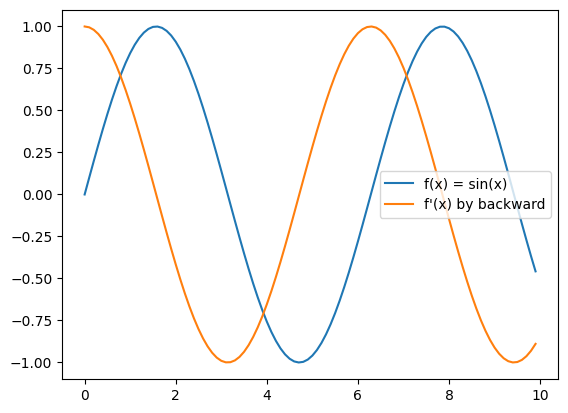

In [22]:
import matplotlib.pyplot as plt
import torch

def f(x):
    return torch.sin(x)

# x 需要开启求导跟踪
x = torch.arange(0, 10, 0.1, requires_grad=True)

# 计算函数值
y = f(x)

# 因为 y 是一个向量，不能直接 y.backward()
# 所以先求和变成标量，再反向传播
y.sum().backward()

# 画原函数
plt.plot(x.detach().numpy(), y.detach().numpy(), label='f(x) = sin(x)')

# 画自动求导得到的导数
plt.plot(x.detach().numpy(), x.grad.detach().numpy(), label="f'(x) by backward")

plt.legend()
plt.show()